In [1]:
# === Imports ===
import os
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from cycler import cycler
from matplotlib.ticker import (
    ScalarFormatter,
    LogLocator,
    FuncFormatter
)

# === Reproducibility ===
np.random.seed(42)

# === Global Plot Styling ===
mpl.rcParams["font.family"] = "Arial"

PLOT_PARAMS = {
    "legend.fontsize": 8,
    "figure.figsize": (6.5, 3),
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 5,
    "lines.linewidth": 1,
}

plt.rcParams.update(PLOT_PARAMS)

# === Color Palette ===
CUSTOM_PALETTE = [
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
    "#7A1F63",  # dark purple
]

# === Line Styles ===
LINESTYLES = [
    "-",
    "-",
    "-",
    "--",
    "-.",
    ":",
    "-"
]

# Optional custom dash patterns
SEALINES = [
    "",
    "",
    (6, 4),
    (6, 4),
    (3, 5, 1, 5),
    (1, 3),
    ""
]

# === Apply Style Cycle ===
sns.set_palette(CUSTOM_PALETTE)

plt.rcParams["axes.prop_cycle"] = (
    cycler(color=CUSTOM_PALETTE)
    + cycler(linestyle=LINESTYLES)
)

# === Utility Functions ===
def rotate_points(x, y, theta_deg):
    """
    Rotate points by theta_deg degrees clockwise.

    Parameters
    ----------
    x, y : array-like
        Coordinates to rotate.
    theta_deg : float
        Rotation angle in degrees.

    Returns
    -------
    x_rot, y_rot : ndarray
        Rotated coordinates.
    """
    theta = np.deg2rad(theta_deg)

    x_rot = x * np.cos(theta) + y * np.sin(theta)
    y_rot = -x * np.sin(theta) + y * np.cos(theta)

    return x_rot, y_rot

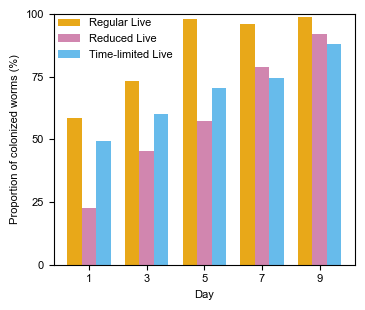


Mean ± SD of colonization (%) per day:

Day 1:
  Regular Live       : 58.67 ± 49.57
  Reduced Live       : 22.67 ± 42.15
  Time-limited Live  : 49.33 ± 50.33


Individual colonization percentages per day:

Day 3:
  Regular Live       : 73.33 ± 44.52
  Reduced Live       : 45.33 ± 50.12
  Time-limited Live  : 60.00 ± 49.32


Individual colonization percentages per day:

Day 5:
  Regular Live       : 98.00 ± 14.14
  Reduced Live       : 57.33 ± 49.79
  Time-limited Live  : 70.67 ± 45.84


Individual colonization percentages per day:

Day 7:
  Regular Live       : 95.95 ± 19.86
  Reduced Live       : 78.67 ± 41.24
  Time-limited Live  : 74.67 ± 43.78


Individual colonization percentages per day:

Day 9:
  Regular Live       : 98.67 ± 11.55
  Reduced Live       : 92.00 ± 27.31
  Time-limited Live  : 88.00 ± 32.71


Individual colonization percentages per day:

Day 1:
  Regular Live       : [100.0, 100.0, 100.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 100.0, 0.0, 0.0, 100.0, 0.0, 100.0, 100.0, 100.

In [2]:
#Figure 2b)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


days = [1, 3, 5, 7, 9]

colorExp1 = "#E69F00"
colorExp2 = "#CC79A7"
colorExp3 = "#56b4e9"

bar_width = 0.25

folderExp1 = r"Exp_1_Ecoli_population_outputs\csv"
cleanExp1 = "Exp_1_Ecoli_population_CLEANED.csv"
clean_dataExp1 = pd.read_csv(os.path.join(folderExp1, cleanExp1))

folderExp2 = r"Exp_2_Reduced_live_feed_data_outputs\csv"
cleanExp2 = "Exp_2_Reduced_live_feed_data_CLEANED.csv"
clean_dataExp2 = pd.read_csv(os.path.join(folderExp2, cleanExp2))

folderExp3 = r"Exp_3_Stochasticity_data_outputs\csv"
cleanExp3 = "Exp_3_Stochasticity_data_CLEANED.csv"
clean_dataExp3 = pd.read_csv(os.path.join(folderExp3, cleanExp3))

p1, p2, p3 = [], [], []

for day in days:

    df1 = clean_dataExp1[clean_dataExp1["Day"] == day]
    p1.append((1-(df1["Counts"] == 0).mean()) * 100)

    df2 = clean_dataExp2[clean_dataExp2["Day"] == day]
    p2.append((1-(df2["Counts"] == 0).mean()) * 100)

    df3 = clean_dataExp3[clean_dataExp3["Day"] == day]
    p3.append((1-(df3["Counts"] == 0).mean()) * 100)


x = np.arange(len(days))


fig, ax = plt.subplots(figsize=(3.75, 3.2))

ax.bar(x - bar_width, p1, width=bar_width, color=colorExp1, alpha=0.9, label="Regular Live")
ax.bar(x, p2, width=bar_width, color=colorExp2, alpha=0.9, label="Reduced Live")
ax.bar(x + bar_width, p3, width=bar_width, color=colorExp3, alpha=0.9, label="Time-limited Live")


ax.set_xticks(x)
ax.set_xticklabels(days)

ax.set_ylim(0,100)
ax.set_yticks([0,25,50,75,100])

ax.set_xlabel("Day", fontsize=8)
ax.set_ylabel("Proportion of colonized worms (%)", fontsize=8)




ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper left",
    borderaxespad=0.0
)

plt.tight_layout()


plt.savefig(
    r"Zero_Count_Percentage_By_Day.svg",
    bbox_inches="tight",
    format="svg"
)

plt.show()

print("\nMean ± SD of colonization (%) per day:\n")

for day in days:
    df1 = clean_dataExp1[clean_dataExp1["Day"] == day]
    vals1 = (df1["Counts"] > 0).astype(float) * 100

    df2 = clean_dataExp2[clean_dataExp2["Day"] == day]
    vals2 = (df2["Counts"] > 0).astype(float) * 100

    df3 = clean_dataExp3[clean_dataExp3["Day"] == day]
    vals3 = (df3["Counts"] > 0).astype(float) * 100

    mean1, sd1 = vals1.mean(), vals1.std()
    mean2, sd2 = vals2.mean(), vals2.std()
    mean3, sd3 = vals3.mean(), vals3.std()

    print(f"Day {day}:")
    print(f"  Regular Live       : {mean1:.2f} ± {sd1:.2f}")
    print(f"  Reduced Live       : {mean2:.2f} ± {sd2:.2f}")
    print(f"  Time-limited Live  : {mean3:.2f} ± {sd3:.2f}")
    print()


    print("\nIndividual colonization percentages per day:\n")

for day in days:
    df1 = clean_dataExp1[clean_dataExp1["Day"] == day]
    vals1 = (df1["Counts"] > 0).astype(float) * 100

    df2 = clean_dataExp2[clean_dataExp2["Day"] == day]
    vals2 = (df2["Counts"] > 0).astype(float) * 100

    df3 = clean_dataExp3[clean_dataExp3["Day"] == day]
    vals3 = (df3["Counts"] > 0).astype(float) * 100

    print(f"Day {day}:")
    print(f"  Regular Live       : {vals1.tolist()}")
    print(f"  Reduced Live       : {vals2.tolist()}")
    print(f"  Time-limited Live  : {vals3.tolist()}\n")

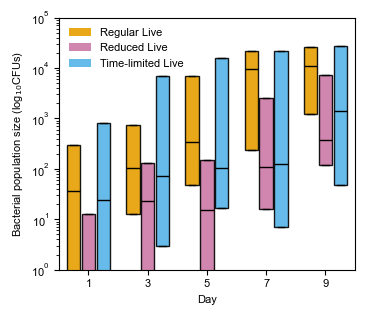

In [3]:
#Figure 2c)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ----------------------------- 
# SETTINGS
# ----------------------------- 
days = [1, 3, 5, 7, 9]

colorExp1 = "#E69F00"
colorExp2 = "#CC79A7"
colorExp3 = "#56b4e9"

colors = [colorExp1, colorExp2, colorExp3]
diets = ["Regular Live", "Reduced Live", "Time-limited Live"]

# small offsets so boxes don't overlap
offsets = [-0.5, 0, 0.5]


df = pd.read_csv(
    r"quartile_tail_density_summary_1-3.csv"
)

experiments = df['experiment'].unique()


fig, ax = plt.subplots(figsize=(3.75, 3.25))


boxes = []
positions = []
box_colors = []

for d_i, day in enumerate(days):

    df_day = df[df["day"] == day]

    for e_i, exp in enumerate(experiments):

        row = df_day[df_day["experiment"] == exp].iloc[0]

        box = {
            'med': row['Q50'],
            'q1': row['Q25'],
            'q3': row['Q75'],
            'whislo': row['Q25'],
            'whishi': row['Q75'],
            'fliers': []
        }

        boxes.append(box)
        positions.append(day + offsets[e_i])
        box_colors.append(colors[e_i])


bxp = ax.bxp(
    boxes,
    positions=positions,
    widths=0.45,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color='black')
)

# apply colors
for patch, color in zip(bxp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)


ax.set_yscale("log")
ax.set_ylim(1, 1e5)

ax.set_xticks(days)
ax.set_xlabel("Day", fontsize=8)
ax.set_ylabel("Bacterial population size (log$_{\mathrm{10}}$CFUs)", fontsize=8)


handles = [
    Patch(facecolor=colors[i], alpha=0.9, label=diets[i])
    for i in range(len(diets))
]

ax.legend(
    handles=handles,
    loc="upper left",
    frameon=False,
    fontsize=8
)
ax.set_xticks(days)
ax.set_xticklabels([str(d) for d in days])
plt.tight_layout()

plt.savefig(
    r"Quartile_Tail_Density_AllDays.svg",
    bbox_inches="tight",
    format="svg"
)

plt.show()

     Day  Counts  Dilution  Exp
0      1       4       2.2    1
1      1     105       2.2    1
2      1       1       2.2    1
3      1       0       2.2    1
4      1      17       2.2    1
..   ...     ...       ...  ...
368    9      77    2222.0    3
369    9     106     222.0    3
370    9      54     222.0    3
371    9     159       2.2    3
372    9      43     222.0    3

[373 rows x 4 columns]
     Day  Counts  Dilution  Exp
0      1       7       2.2    1
1      1       1       2.2    1
2      1       0       2.2    1
3      1       0       2.2    1
4      1       0       2.2    1
..   ...     ...       ...  ...
368    9       6       2.2    3
369    9       2       2.2    3
370    9       0       2.2    3
371    9      45       2.2    3
372    9       0       2.2    3

[373 rows x 4 columns]
[np.float64(82.66666666666667), np.float64(79.72972972972973), np.float64(95.94594594594594), np.float64(100.0), np.float64(97.33333333333334)]
[np.float64(43.24324324324324), np.float

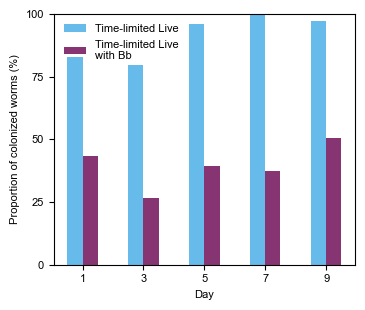


Mean ± SD of colonization (%) per day:

Day 1:
  Time-limited Live       : 82.67 ± 38.11
  Time-limited Live with Bb  : 43.24 ± 49.88

Day 3:
  Time-limited Live       : 79.73 ± 40.48
  Time-limited Live with Bb  : 26.67 ± 44.52

Day 5:
  Time-limited Live       : 95.95 ± 19.86
  Time-limited Live with Bb  : 39.19 ± 49.15

Day 7:
  Time-limited Live       : 100.00 ± 0.00
  Time-limited Live with Bb  : 37.33 ± 48.69

Day 9:
  Time-limited Live       : 97.33 ± 16.22
  Time-limited Live with Bb  : 50.67 ± 50.33

   Day                 Time-limited Live         Time-limited Live with Bb
0    1                [72.0, 88.0, 88.0]   [48.0, 12.0, 70.83333333333334]
1    3  [96.0, 88.0, 54.166666666666664]   [48.0, 4.0, 28.000000000000004]
2    5  [96.0, 100.0, 91.66666666666666]  [36.0, 20.833333333333336, 60.0]
3    7             [100.0, 100.0, 100.0]                [44.0, 32.0, 36.0]
4    9              [92.0, 100.0, 100.0]                [40.0, 40.0, 72.0]


In [4]:
#Figure 3b)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


days = [1, 3, 5, 7, 9]

# Experiment 4
folderExp1 =  r"Exp_7_low-salinity_time-limited_outputs\csv"
cleanExp1 = "Exp_7_low-salinity_time-limited_CLEANED.csv"
extensionExp1 = "Exp_7_low-salinity_time-limited_day"
colorExp1 = "#56b4e9"
clean_fileExp1 = os.path.join(folderExp1, cleanExp1)
clean_dataExp1 = pd.read_csv(clean_fileExp1)

# Experiment 5
folderExp2 = r"Exp_8_BB_low-salinity_time-limited_outputs\csv"
cleanExp2 = "Exp_8_BB_low-salinity_time-limited_CLEANED.csv"
extensionExp2 = "Exp_8_BB_low-salinity_time-limited_day"
colorExp2 = "#7A1F63"
clean_fileExp2 = os.path.join(folderExp2, cleanExp2)
clean_dataExp2 = pd.read_csv(clean_fileExp2)
print(clean_dataExp1)
print(clean_dataExp2)
#clean_dataExp2 = clean_dataExp2[~((clean_dataExp2["Exp"] == 2) & (clean_dataExp2["Day"] == 1))]


p1, p2 = [], []

for day in days:

    df1 = clean_dataExp1[clean_dataExp1["Day"] == day]
    p1.append((1-(df1["Counts"] == 0).mean()) * 100)

    df2 = clean_dataExp2[clean_dataExp2["Day"] == day]
    p2.append((1-(df2["Counts"] == 0).mean()) * 100)




x = np.arange(len(days))


fig, ax = plt.subplots(figsize=(3.75, 3.2))
print(p1)
print(p2)
ax.bar(x - 0.5*bar_width, p1, width=bar_width, color=colorExp1, alpha=0.9, label="Time-limited Live")
ax.bar(x + 0.5*bar_width, p2, width=bar_width, color=colorExp2, alpha=0.9, label="Time-limited Live\nwith Bb")


ax.set_xticks(x)
ax.set_xticklabels(days)

ax.set_ylim(0,100)
ax.set_yticks([0,25,50,75,100])

ax.set_xlabel("Day", fontsize=8)
ax.set_ylabel("Proportion of colonized worms (%)", fontsize=8)




ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper left"
)

plt.tight_layout()


plt.savefig(
    r"Zero_Count_Percentage_By_Day7_8.svg",
    bbox_inches="tight",
    format="svg"
)

plt.show()


print("\nMean ± SD of colonization (%) per day:\n")

for day in days:
    df1 = clean_dataExp1[clean_dataExp1["Day"] == day]
    vals1 = (df1["Counts"] > 0).astype(float) * 100

    df2 = clean_dataExp2[clean_dataExp2["Day"] == day]
    vals2 = (df2["Counts"] > 0).astype(float) * 100



    mean1, sd1 = vals1.mean(), vals1.std()
    mean2, sd2 = vals2.mean(), vals2.std()

    print(f"Day {day}:")
    print(f"  Time-limited Live       : {mean1:.2f} ± {sd1:.2f}")
    print(f"  Time-limited Live with Bb  : {mean2:.2f} ± {sd2:.2f}")
    print()
def replicate_percentages(df_day):
    """Return list of % colonized per Exp for a given day"""
    pct_list = []
    for exp_id in sorted(df_day["Exp"].unique()):
        df_exp = df_day[df_day["Exp"] == exp_id]
        pct = (df_exp["Counts"] > 0).mean() * 100
        pct_list.append(pct)
    return pct_list


rows = []
for day in days:
    df1_day = clean_dataExp1[clean_dataExp1["Day"] == day]
    df2_day = clean_dataExp2[clean_dataExp2["Day"] == day]

    row = {
        "Day": day,
        "Time-limited Live": replicate_percentages(df1_day),
        "Time-limited Live with Bb": replicate_percentages(df2_day) if len(df2_day) > 0 else []
    }
    rows.append(row)

wide_table = pd.DataFrame(rows)

# Display table
print(wide_table)


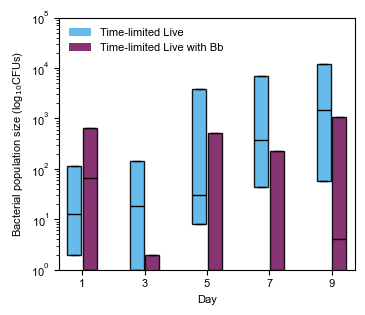

In [5]:
#Figure 3c)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


days = [1, 3, 5, 7, 9]

colorExp1 = "#56b4e9"
colorExp2 = "#7A1F63"

colors = [colorExp1, colorExp2]
diets = ["Time-limited Live", "Time-limited Live with Bb"]



# small offsets so boxes don't overlap
offsets = [-0.25, 0.25]


df = pd.read_csv(
    r"quartile_tail_density_summary_7-8.csv"
)

experiments = df['experiment'].unique()

fig, ax = plt.subplots(figsize=(3.75, 3.25))


boxes = []
positions = []
box_colors = []

for d_i, day in enumerate(days):

    df_day = df[df["day"] == day]

    for e_i, exp in enumerate(experiments):

        row = df_day[df_day["experiment"] == exp].iloc[0]

        box = {
            'med': row['Q50'],
            'q1': row['Q25'],
            'q3': row['Q75'],
            'whislo': row['Q25'],
            'whishi': row['Q75'],
            'fliers': []
        }

        boxes.append(box)
        positions.append(day + offsets[e_i])
        box_colors.append(colors[e_i])


bxp = ax.bxp(
    boxes,
    positions=positions,
    widths=0.45,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color='black')
)

# apply colors
for patch, color in zip(bxp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)


ax.set_yscale("log")
ax.set_ylim(1, 1e5)

ax.set_xticks(days)
ax.set_xlabel("Day", fontsize=8)
ax.set_ylabel("Bacterial population size (log$_{\mathrm{10}}$CFUs)", fontsize=8)


handles = [
    Patch(facecolor=colors[i], alpha=0.9, label=diets[i])
    for i in range(len(diets))
]

ax.legend(
    handles=handles,
    loc="upper left",
    frameon=False,
    fontsize=8
)
ax.set_xticks(days)
ax.set_xticklabels([str(d) for d in days])
plt.tight_layout()

plt.savefig(
    r"Quartile_Tail_Density_AllDays_7-8.svg",
    bbox_inches="tight",
    format="svg"
)

plt.show()

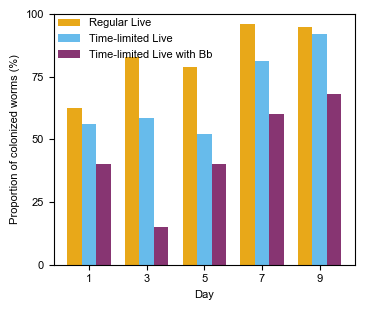


Mean ± SD of colonization (%) per day:

Day 1:
  Regular Live       : 62.67 ± 48.69
  Time-limited Live       : 56.00 ± 49.97
  Time-limited Live with Bb  : 40.00 ± 49.32

Day 3:
  Regular Live       : 82.67 ± 38.11
  Time-limited Live       : 58.67 ± 49.57
  Time-limited Live with Bb  : 14.86 ± 35.82

Day 5:
  Regular Live       : 78.67 ± 41.24
  Time-limited Live       : 52.00 ± 50.30
  Time-limited Live with Bb  : 40.00 ± 49.32

Day 7:
  Regular Live       : 96.00 ± 19.73
  Time-limited Live       : 81.33 ± 39.23
  Time-limited Live with Bb  : 60.00 ± 49.32

Day 9:
  Regular Live       : 94.67 ± 22.62
  Time-limited Live       : 92.00 ± 27.31
  Time-limited Live with Bb  : 68.00 ± 46.96



In [6]:
#Figure S3b
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


days = [1, 3, 5, 7, 9]
# Experiment 4
folderExp1 = r"Exp_4_Regular_Feed_pH7.3_data_outputs\csv"
cleanExp1 = "Exp_4_Regular_Feed_pH7.3_data_CLEANED.csv"
extensionExp1 = "Exp_4_Regular_Feed_pH7.3_data_day"
colorExp1 = "#E69F00"
clean_fileExp1 = os.path.join(folderExp1, cleanExp1)
clean_dataExp1 = pd.read_csv(clean_fileExp1)

# Experiment 5
folderExp2 = r"Exp_5_TL_highpH_data_outputs\csv"
cleanExp2 = "Exp_5_TL_highpH_data_CLEANED.csv"
extensionExp2 = "Exp_5_TL_highpH_data_day"
colorExp2 = "#56b4e9"
clean_fileExp2 = os.path.join(folderExp2, cleanExp2)
clean_dataExp2 = pd.read_csv(clean_fileExp2)

# Experiment 6
folderExp3 = r"Exp_6_BB_TL_highpH_outputs\csv"
cleanExp3 = "Exp_6_BB_TL_highpH_CLEANED.csv"
extensionExp3 = "Exp_6_BB_TL_highpH_day"
colorExp3 = "#7A1F63"
clean_fileExp3 = os.path.join(folderExp3, cleanExp3)
clean_dataExp3 = pd.read_csv(clean_fileExp3)
bar_width = 0.25


p1, p2, p3 = [], [], []

for day in days:

    df1 = clean_dataExp1[clean_dataExp1["Day"] == day]
    p1.append((1-(df1["Counts"] == 0).mean()) * 100)

    df2 = clean_dataExp2[clean_dataExp2["Day"] == day]
    p2.append((1-(df2["Counts"] == 0).mean()) * 100)

    df3 = clean_dataExp3[clean_dataExp3["Day"] == day]
    p3.append((1-(df3["Counts"] == 0).mean()) * 100)


x = np.arange(len(days))


fig, ax = plt.subplots(figsize=(3.75, 3.2))

ax.bar(x - bar_width, p1, width=bar_width, color=colorExp1, alpha=0.9, label="Regular Live")
ax.bar(x, p2, width=bar_width, color=colorExp2, alpha=0.9, label="Time-limited Live")
ax.bar(x + bar_width, p3, width=bar_width, color=colorExp3, alpha=0.9, label="Time-limited Live with Bb")


ax.set_xticks(x)
ax.set_xticklabels(days)

ax.set_ylim(0,100)
ax.set_yticks([0,25,50,75,100])

ax.set_xlabel("Day", fontsize=8)
ax.set_ylabel("Proportion of colonized worms (%)", fontsize=8)




ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper left",
    borderaxespad=0.0
)

plt.tight_layout()


plt.savefig(
    r"Zero_Count_Percentage_By_Day_4_5_6.svg",
    bbox_inches="tight",
    format="svg"
)

plt.show()


print("\nMean ± SD of colonization (%) per day:\n")

for day in days:
    df1 = clean_dataExp1[clean_dataExp1["Day"] == day]
    vals1 = (df1["Counts"] > 0).astype(float) * 100

    df2 = clean_dataExp2[clean_dataExp2["Day"] == day]
    vals2 = (df2["Counts"] > 0).astype(float) * 100

    df3 = clean_dataExp3[clean_dataExp3["Day"] == day]
    vals3 = (df3["Counts"] > 0).astype(float) * 100

    mean1, sd1 = vals1.mean(), vals1.std()
    mean2, sd2 = vals2.mean(), vals2.std()
    mean3, sd3 = vals3.mean(), vals3.std()

    print(f"Day {day}:")
    print(f"  Regular Live       : {mean1:.2f} ± {sd1:.2f}")
    print(f"  Time-limited Live       : {mean2:.2f} ± {sd2:.2f}")
    print(f"  Time-limited Live with Bb  : {mean3:.2f} ± {sd3:.2f}")
    print()

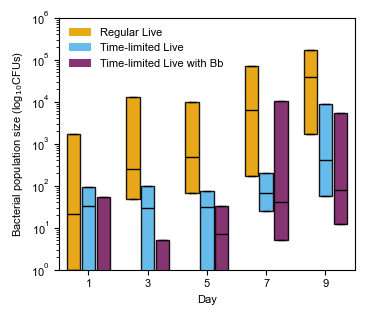

In [7]:
#Figure S3c
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


days = [1, 3, 5, 7, 9]


colorExp1 = "#E69F00"
colorExp2 = "#56b4e9"
colorExp3 = "#7A1F63"

colors = [colorExp1, colorExp2, colorExp3]
diets = ["Regular Live", "Time-limited Live", "Time-limited Live with Bb"]

df = pd.read_csv(
    r"quartile_tail_density_summary_4-6.csv"
)
offsets = [-0.5, 0, 0.5]

experiments = df['experiment'].unique()


fig, ax = plt.subplots(figsize=(3.75, 3.25))


boxes = []
positions = []
box_colors = []

for d_i, day in enumerate(days):

    df_day = df[df["day"] == day]

    for e_i, exp in enumerate(experiments):

        row = df_day[df_day["experiment"] == exp].iloc[0]

        box = {
            'med': row['Q50'],
            'q1': row['Q25'],
            'q3': row['Q75'],
            'whislo': row['Q25'],
            'whishi': row['Q75'],
            'fliers': []
        }

        boxes.append(box)
        positions.append(day + offsets[e_i])
        box_colors.append(colors[e_i])


bxp = ax.bxp(
    boxes,
    positions=positions,
    widths=0.45,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color='black')
)

# apply colors
for patch, color in zip(bxp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)


ax.set_yscale("log")
ax.set_ylim(1, 1e6)

ax.set_xticks(days)
ax.set_xlabel("Day", fontsize=8)
ax.set_ylabel("Bacterial population size (log$_{\mathrm{10}}$CFUs)", fontsize=8)


handles = [
    Patch(facecolor=colors[i], alpha=0.9, label=diets[i])
    for i in range(len(diets))
]

ax.legend(
    handles=handles,
    loc="upper left",
    frameon=False,
    fontsize=8
)
ax.set_xticks(days)
ax.set_xticklabels([str(d) for d in days])
plt.tight_layout()

plt.savefig(
    r"Quartile_Tail_Density_AllDays_4-6.svg",
    bbox_inches="tight",
    format="svg"
)

plt.show()

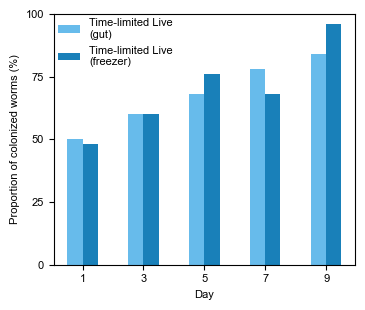


--- Gut Condition ---

Mean ± SD of colonization (%) per day:

Day 1: 50.00 ± 50.51
Day 3: 60.00 ± 49.49
Day 5: 68.00 ± 47.12
Day 7: 78.00 ± 41.85
Day 9: 84.00 ± 37.03

--- Freezer Condition ---

Mean ± SD of colonization (%) per day:

Day 1: 48.00 ± 50.99
Day 3: 60.00 ± 50.00
Day 5: 76.00 ± 43.59
Day 7: 68.00 ± 47.61
Day 9: 96.00 ± 20.00


In [8]:
#Figure S10a
# === Standard Library Imports ===
import os

# === Scientific Computing ===
import numpy as np
import pandas as pd

# === Plotting ===
import matplotlib.pyplot as plt


DAYS = [1, 3, 5, 7, 9]

BAR_WIDTH = 0.25

COLORS = {
    "gut": "#56B4E9",
    "freezer": "#0072B2",
    
}


FOLDER_EXP1 = (
    r"Exp_3_Stochasticity_data_freezer_outputs\csv"
)

FOLDER_EXP2 = (
    r"Exp_3_Stochasticity_data_gut_outputs\csv"
)

FILE_EXP1 = "Exp_3_Stochasticity_data_freezer_CLEANED.csv"
FILE_EXP2 = "Exp_3_Stochasticity_data_gut_CLEANED.csv"

SAVE_PATH = (
    r"Zero_Count_Percentage_By_Day_exp3_gut_freezer.svg"
)

data_exp1 = pd.read_csv(os.path.join(FOLDER_EXP1, FILE_EXP1))
data_exp2 = pd.read_csv(os.path.join(FOLDER_EXP2, FILE_EXP2))


def calculate_colonization_percentage(df, days):
    """
    Calculate percentage of colonized worms per day.

    Colonized worms are defined as Counts > 0.
    """
    percentages = []

    for day in days:
        day_df = df[df["Day"] == day]

        percent_colonized = (
            1 - (day_df["Counts"] == 0).mean()
        ) * 100

        percentages.append(percent_colonized)

    return percentages


def summarize_colonization(df, days):
    """
    Print mean ± SD colonization percentages per day.
    """
    print("\nMean ± SD of colonization (%) per day:\n")

    for day in days:
        day_df = df[df["Day"] == day]

        values = (day_df["Counts"] > 0).astype(float) * 100

        mean = values.mean()
        sd = values.std()

        print(f"Day {day}: {mean:.2f} ± {sd:.2f}")


percent_gut = calculate_colonization_percentage(
    data_exp2,
    DAYS
)

percent_freezer = calculate_colonization_percentage(
    data_exp1,
    DAYS
)

x = np.arange(len(DAYS))


fig, ax = plt.subplots(figsize=(3.75, 3.2))

# --- Bars ---
ax.bar(
    x - BAR_WIDTH * 0.5,
    percent_gut,
    width=BAR_WIDTH,
    color=COLORS["gut"],
    alpha=0.9,
    label="Time-limited Live\n(gut)"
)

ax.bar(
    x + BAR_WIDTH * 0.5,
    percent_freezer,
    width=BAR_WIDTH,
    color=COLORS["freezer"],
    alpha=0.9,
    label="Time-limited Live\n(freezer)"
)


ax.set_xticks(x)
ax.set_xticklabels(DAYS)

ax.set_ylim(0, 100)
ax.set_yticks([0, 25, 50, 75, 100])

ax.set_xlabel("Day", fontsize=8)
ax.set_ylabel(
    "Proportion of colonized worms (%)",
    fontsize=8
)


ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper left",
    borderaxespad=0.0
)

plt.tight_layout()

plt.savefig(
    SAVE_PATH,
    bbox_inches="tight",
    format="svg"
)

plt.show()

print("\n--- Gut Condition ---")
summarize_colonization(data_exp2, DAYS)

print("\n--- Freezer Condition ---")
summarize_colonization(data_exp1, DAYS)

In [9]:
import os
import re

import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# === Plotting ===
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from cycler import cycler
from matplotlib.ticker import (
    ScalarFormatter,
    LogLocator,
    FuncFormatter
)

import seaborn as sns

np.random.seed(42)

mpl.rcParams["font.family"] = "Arial"

PLOT_PARAMS = {
    "legend.fontsize": 8,
    "figure.figsize": (6.5, 3),
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 5,
    "lines.linewidth": 1,
}

plt.rcParams.update(PLOT_PARAMS)

CUSTOM_PALETTE = [
    "#CC79A7",  # reddish purple
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#7A1F63",  # dark purple
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
]

LINESTYLES = [
    "-",
    "-",
    "--",
    "--",
    "-.",
    ":",
    "-"
]

SEALINES = [
    "",
    "",
    (6, 4),
    (6, 4),
    (3, 5, 1, 5),
    (1, 3),
    ""
]

sns.set_palette(CUSTOM_PALETTE)

plt.rcParams["axes.prop_cycle"] = (
    cycler(color=CUSTOM_PALETTE)
    + cycler(linestyle=LINESTYLES)
)

def rotate_points(x, y, theta_deg):
    """
    Rotate points clockwise by theta_deg degrees.

    Parameters
    ----------
    x, y : array-like
        Coordinates to rotate.
    theta_deg : float
        Rotation angle in degrees.

    Returns
    -------
    x_rot, y_rot : ndarray
        Rotated coordinates.
    """
    theta = np.deg2rad(theta_deg)

    x_rot = x * np.cos(theta) + y * np.sin(theta)
    y_rot = -x * np.sin(theta) + y * np.cos(theta)

    return x_rot, y_rot

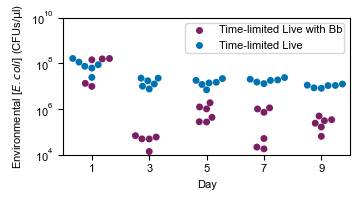

In [10]:
#Figure 3d)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter


df = pd.read_csv(r"Low_Salt_Environment_combined.csv")

df["Day"] = pd.to_numeric(df["Day"])
df["Reconstructed"] = pd.to_numeric(df["Reconstructed"]) * 0.9  # single scaling

# Make categorical day axis
df["string_day"] = df["Day"].astype(str)

# Remove unwanted experiment
df = df[df["Exp"] != "ST088"]


fig, ax = plt.subplots(figsize=(3.7, 2.1))

# Define palette matching actual BB column values
palette = {
    "Bb": "#7A1F63",       # Time-limited Live with Bb
    "Control": "#0072B2"   # Time-limited Live
}

sns.swarmplot(
    data=df,
    x="string_day",
    y="Reconstructed",   # use the column directly, no extra scaling
    hue="BB",
    dodge=False,
    palette=palette,
    ax=ax
)


formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((7, 9))
ax.yaxis.set_major_formatter(formatter)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(8, 8))

# Modify offset text
offset = ax.yaxis.get_offset_text()
offset.set_text(r"$\times 10^8$")
offset.set_fontsize(8)


ax.set_xlabel("Day")
ax.set_ylabel(r"Environmental [$\it{E. coli}$] (CFUs/$\mathrm{\mu}$l)")
ax.set_yscale("log")
ax.set_ylim(1e4, 1e10)
ax.set_xlim(-0.5, 4.5)


handles, labels = ax.get_legend_handles_labels()
label_map = {
    "Bb": "Time-limited Live with Bb",
    "Control": "Time-limited Live"
}

ax.legend(
    handles,
    [label_map[l] for l in labels],
    title="",
    borderpad=0.2,
    loc="upper right",
    frameon=True
)


plt.tight_layout()
plt.savefig(
    r"environment_low_salt.svg",
    format="svg",
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

C:\Users\stani\AppData\Local\Temp\ipykernel_33620\946893241.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["PFU_bin", "CFU_bin"])


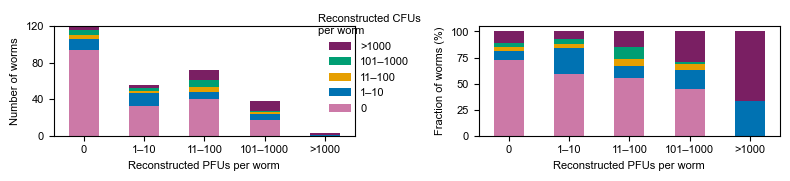

In [11]:

#Figure S5

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy.stats import pearsonr
from matplotlib.ticker import ScalarFormatter

file = r"Exp_8_CFU_vs_PFU_noday1.csv"
data = pd.read_csv(file)

data["string_day"] = data["Day"].astype(str)
data["BB_value"] = data["ReconPFU"]
data["value"] = data["ReconCFU"]

data["is_0"] = data["value"] == 0


bins = [-0.1, 0, 10, 100, 1000, 1000000]
labels = ["0", "1–10", "11–100", "101–1000", ">1000"]

data["PFU_bin"] = pd.cut(data["BB_value"], bins=bins, labels=labels)
data["CFU_bin"] = pd.cut(data["value"], bins=bins, labels=labels)

count_table = (
    data
    .groupby(["PFU_bin", "CFU_bin"])
    .size()
    .unstack(fill_value=0)
)

count_table_norm = count_table.div(count_table.sum(axis=1), axis=0) * 100


fig, axes = plt.subplots(1, 2, figsize=(8, 2), sharex=True)


count_table.plot(
    kind="bar",
    stacked=True,
    ax=axes[0]
)

axes[0].set_xlabel("Reconstructed PFUs per worm")
axes[0].set_ylabel("Number of worms")
axes[0].set_xticklabels(labels, rotation=0)
axes[0].set_yticks([0, 40, 80, 120])
axes[0].set_ylim(0, 120)

# Legend (only here)
handles, legend_labels = axes[0].get_legend_handles_labels()
axes[0].legend(
    handles[::-1],
    legend_labels[::-1],
    title="Reconstructed CFUs\nper worm",
    fontsize=8,
    title_fontsize=8,
    loc='upper right',
    frameon=False,
    bbox_to_anchor=(1.25, 1.2)
)


count_table_norm.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    legend=False  # no duplicate legend
)

axes[1].set_xlabel("Reconstructed PFUs per worm")
axes[1].set_ylabel("Fraction of worms (%)")
axes[1].set_xticklabels(labels, rotation=0)
axes[1].set_yticks([0, 25, 50, 75, 100])
# --------------------------------
# FINAL FORMATTING
# --------------------------------
plt.tight_layout()

plt.savefig(
    r"ST088_Bb_PFU_vs_CFU_combined_Carol.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

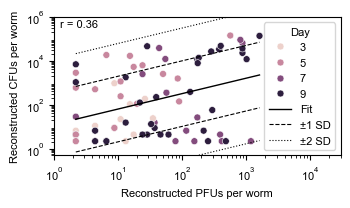

In [12]:
#Figure 3e)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


mask = (data["BB_value"] > 0) & (data["value"] > 0)
x = data.loc[mask, "BB_value"]
y = data.loc[mask, "value"]

# Log-transform
logx = np.log10(x)
logy = np.log10(y)

# Linear fit
slope, intercept = np.polyfit(logx, logy, 1)

# Pearson r
r, p = pearsonr(logx, logy)


logy_pred = intercept + slope * logx
residuals = logy - logy_pred
sigma = np.std(residuals)


x_fit = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)

logy_fit = intercept + slope * np.log10(x_fit)

# Convert back to linear space
y_fit = 10**logy_fit
y_fit_1sd_up = 10**(logy_fit + sigma)
y_fit_1sd_down = 10**(logy_fit - sigma)
y_fit_2sd_up = 10**(logy_fit + 2*sigma)
y_fit_2sd_down = 10**(logy_fit - 2*sigma)


plt.figure(figsize=(3.7, 1.8))

# Scatter
sns.scatterplot(data=data, x="BB_value", y="value", hue="Day")

# Best-fit line (smooth)
plt.plot(x_fit, y_fit, color="black", label="Fit")

# ±1 SD
plt.plot(x_fit, y_fit_1sd_up, color="black", linestyle="--", linewidth=0.8)
plt.plot(x_fit, y_fit_1sd_down, color="black", linestyle="--", linewidth=0.8,label="±1 SD")

# ±2 SD
plt.plot(x_fit, y_fit_2sd_up, color="black", linestyle=":", linewidth=0.8)
plt.plot(x_fit, y_fit_2sd_down, color="black", linestyle=":", linewidth=0.8,label="±2 SD")

# Log axes
plt.xscale("log")
plt.yscale("log")
plt.xlim(1, 30000)
plt.xlabel("Reconstructed PFUs per worm")
plt.ylabel("Reconstructed CFUs per worm")
plt.ylim(0.5, 1000000)
# r-value
plt.text(
    0.02, 0.98,
    f"r = {r:.2f}",
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=8
)
plt.yticks([1,  100, 10000,  1000000])

plt.legend(title="Day", fontsize=8, title_fontsize=8)

plt.savefig(
    r"ST088_Bb_Cfu_vs_Pfu_log_with_sd_carol.svg",
    format="svg",

    pad_inches=0
)
plt.show()

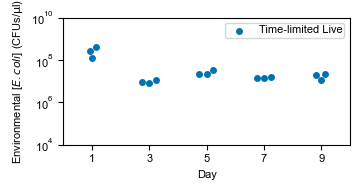

In [13]:
#Figure S4a

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

df = pd.read_csv(r"ST104_pH58_HighSalt_environment.csv")

df["Day"] = pd.to_numeric(df["Day"])
df["Reconstructed"] = pd.to_numeric(df["Reconstructed"]) 

# Make categorical day axis (same as second plot)
df["string_day"] = df["Day"].astype(str)


fig, ax = plt.subplots(figsize=(3.7, 2))

sns.swarmplot(
    data=df,
    x="string_day",
    y=df["Reconstructed"]*.9,
    dodge=False,
    ax=ax,
    color="#0072B2"
)

# Scientific formatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((7, 9))
ax.yaxis.set_major_formatter(formatter)

ax.ticklabel_format(style='scientific', axis='y', scilimits=(8, 8))

# Modify offset text
offset = ax.yaxis.get_offset_text()
offset.set_text(r"$\\times 10^8$")
offset.set_fontsize(8)

# Formatting
ax.set_xlabel("Day")
ax.set_ylabel(r"Environmental [$\it{E. coli}$] (CFUs/$\mathrm{\mu}$l)")
ax.set_yscale("log")
ax.set_ylim(1e4, 1e10)
ax.set_xlim(-0.5, 4.5)

ax.legend(title="", borderpad=0.2, loc="upper right", labels=["Time-limited Live"], frameon=True)

plt.tight_layout()

plt.savefig(
    r"environment_pH58_high_salt.svg",
    format="svg",
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

In [14]:
def process_row(row):
#     print(row["1/20*0.90"] is None and row["1/200*0.90"] is None)
#     print(row["1/200*0.90"] is not None)

    if row["100000"] is not None:
        #print(row["1/20*0.90"])
        correction=100000
        #print(correction)
        try:
            value=int(row["100000"])*correction
            return value,correction       
        except:
#             print(type(row["1/200*0.90"]))
#             print(row["1/200*0.90"]==np.nan, row["1/200*0.90"]==None, pd.isna(row["1/200*0.90"]))
            if pd.isna(row["1000000"]):
                        # Handle case where the string is "unc"
#                 print("here")
#                 print(row["1/20*0.90"].lower())
                if row["100000"].startswith("u"):
                    print("here2")
                    value=500*correction
                    return value,correction

                # Remove non-digit characters and convert to int
                cleaned_value = re.sub(r'\D', '', row["100000"])
                if cleaned_value:
                    value=cleaned_value/correction
                    return value,correction

################################################
    if row["1000000"] is not None:
        #print("here6")
        correction=1000000
        #print(correction)
        try:
            value=int(row["1000000"])*correction
            return value,correction
        except:  
            check = row.get("10000000")
            if check is None or pd.isna(check):
                            # Handle case where the string is "unc"
                # Handle case where the string is "unc"
                if row["1000000"].startswith("u"):
                    value=500*correction
                    return value,correction

                if "-" in row["1000000"]:
                    # Step 1: Split the string by the dash
                    start, end = row["1000000"].split("-")
                    start = int(start)
                    end = int(end)
                    cleaned_value = (start + end) / 2
                else:   
                    # Remove non-digit characters and convert to int
                    cleaned_value = re.sub(r'\D', '', row["1000000"])

                # Return integer if cleaned value is not empty, else None
                print(cleaned_value)
                if cleaned_value:
                    value=int(cleaned_value)/correction
                    return value,correction  
                
    if row["10000000"] is not None:
        correction=10000000
        try:
            value=int(row["10000000"])*correction
            return value,correction
        except:  
            # Handle case where the string is "unc"
            if row["10000000"].startswith("u"):
                value=500*correction
                return value,correction

            if "-" in row["10000000"]:
                # Step 1: Split the string by the dash
                start, end = row["10000000"].split("-")
                start = int(start)
                end = int(end)
                cleaned_value = (start + end) / 2
            else:   
                # Remove non-digit characters and convert to int
                cleaned_value = re.sub(r'\D', '', row["10000000"])

            # Return integer if cleaned value is not empty, else None
            print(cleaned_value)
            if cleaned_value:
                value=int(cleaned_value)*correction
                return value,correction
    else:
        print("ok")
        return None,None

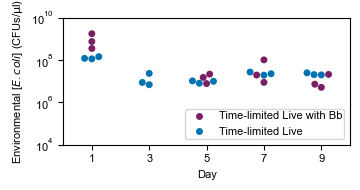

In [15]:
#Figure S4b

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

file_BB = r"Bb_Env_new_smedia.csv"
data_BB = pd.read_csv(file_BB)

data_BB["string_day"] = data_BB["Day"].astype(str)

for index, row in data_BB.iterrows():
    data_BB.loc[index, "value"], data_BB.loc[index, "correction_factor"] = process_row(row)


file_control = r"Environment7.3.csv"
data_control = pd.read_csv(file_control)

data_control["string_day"] = data_control["Day"].astype(str)

for index, row in data_control.iterrows():
    data_control.loc[index, "value"], data_control.loc[index, "correction_factor"] = process_row(row)


data_control["Condition"] = "Time-limited Live"
data_BB["Condition"] = "Time-limited Live with Bb"

# Combine datasets
combined_data = pd.concat([data_BB, data_control], ignore_index=True)

fig, ax = plt.subplots(figsize=(3.7, 2.0))

palette = {
    "Time-limited Live with Bb": "#7A1F63",
    "Time-limited Live": "#0072B2"
}

sns.swarmplot(
    data=combined_data,
    x="string_day",
    y=combined_data["value"]*0.9,      # use raw values, no extra scaling
    hue="Condition",
    dodge=False,
    palette=palette,
    ax=ax
)


formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((7, 9))
ax.yaxis.set_major_formatter(formatter)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(8, 8))

# Modify offset text
offset = ax.yaxis.get_offset_text()
offset.set_text(r"$\times 10^8$")
offset.set_fontsize(8)


ax.set_ylabel(r"Environmental [$\it{E. coli}$] (CFUs/$\mathrm{\mu}$l)")
ax.set_xlabel("Day")
ax.set_yscale("log")
ax.set_ylim(1e4, 1e10)
ax.set_xlim(-0.5, 4.5)


handles, labels = ax.get_legend_handles_labels()
# Ensure consistent order
legend_order = ["Time-limited Live with Bb", "Time-limited Live"]
ax.legend(
    handles=[handles[labels.index(l)] for l in legend_order],
    labels=legend_order,
    title="",
    borderpad=0.2,
    loc="lower right",
    frameon=True
)

plt.tight_layout()
plt.savefig(
    r"environmental_HIGHSALT.svg",
    format="svg",
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

In [16]:
# === Standard Library Imports ===
import os
import re

# === Scientific Computing ===
import numpy as np
import pandas as pd

# === Plotting ===
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from cycler import cycler
from matplotlib.ticker import (
    ScalarFormatter,
    LogLocator,
    FuncFormatter
)

import seaborn as sns

# === Reproducibility ===
np.random.seed(42)

PLOT_PARAMS = {
    "legend.fontsize": 8,
    "figure.figsize": (6.5, 3),
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 5,
    "lines.linewidth": 1,
}

plt.rcParams.update(PLOT_PARAMS)

CUSTOM_PALETTE = [
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
    "#7A1F63",  # dark purple
]

# === Line Styles ===
LINESTYLES = [
    "-",
    "-",
    "--",
    "--",
    "-.",
    ":",
    "-"
]

SEALINES = [
    "",
    "",
    (6, 4),
    (6, 4),
    (3, 5, 1, 5),
    (1, 3),
    ""
]

sns.set_palette(CUSTOM_PALETTE)

plt.rcParams["axes.prop_cycle"] = (
    cycler(color=CUSTOM_PALETTE)
    + cycler(linestyle=LINESTYLES)
)

def rotate_points(x, y, theta_deg):
    """
    Rotate points clockwise by theta_deg degrees.

    Parameters
    ----------
    x, y : array-like
        Coordinates to rotate.
    theta_deg : float
        Rotation angle in degrees.

    Returns
    -------
    x_rot, y_rot : ndarray
        Rotated coordinates.
    """
    theta = np.deg2rad(theta_deg)

    x_rot = x * np.cos(theta) + y * np.sin(theta)
    y_rot = -x * np.sin(theta) + y * np.cos(theta)

    return x_rot, y_rot

In [17]:
#@njit
def logm1exp(x):
    mask = (x>-1)

    res = np.zeros_like(x)
    res[mask] += np.log(-np.expm1(x[mask]))
    res[~mask] += np.log1p(-np.exp(x[~mask]))
    return res

def log_likelihood(ws,lam,ts):
    ll = np.zeros_like(ws)*1.0
    ll[ws] += logm1exp(-(lam*ts)[ws])
    ll[~ws]+= -(lam*ts)[~ws]
    return ll

def find_conf_int(perc,x,py):
    if perc>1:
        perc *=1/100
    py_dens = py/py.sum()
    i = np.argmax(py)
    for j in range(1,py_dens.size//2+1):
        if py_dens[i-j:i+j].sum()>perc:
            return x[i-j+1],x[i+j-1]

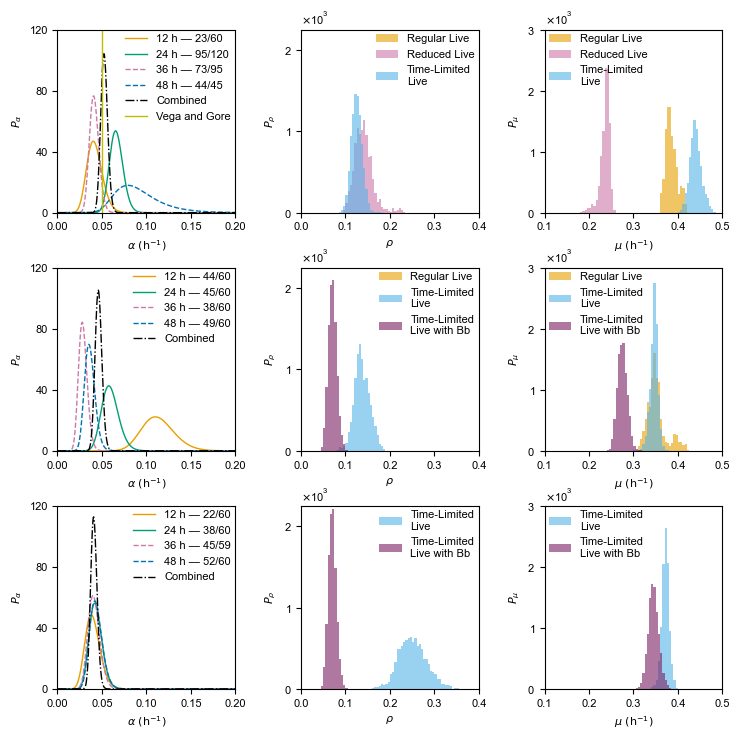

In [18]:
#Figure 4 and Figure S8
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def format_sci(ax):
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((3, 3))  # force 10^2
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))

timePoints = [12, 24, 36, 48]
t = np.linspace(0, 4/20, 501) + 1e-5
dt = t[1] - t[0]

steriledW_all = [
    [37, 25, 22, 1],      # Data 1
    [16, 15, 22, 11],     # Data 2 Was 16,16,16,11 but potential change to 16,15,21,11
    [38, 22, 14, 8]       # Data 3
]

totalW_all = [
    [60, 120, 95, 45],   # Data 1
    [60, 60, 60, 60],    # Data 2
    [60, 60, 59, 60]     # Data 3
]

titles = ["Data 1", "Data 2", "Data 3"]


input_path = r"inference_results_combined.csv"
df = pd.read_csv(input_path)

groups = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8]
]

exp_colors = {
    1: "#E69F00",
    2: "#CC79A7",
    3: "#56B4E9",
    4: "#E69F00",
    5: "#56B4E9",
    6: "#7A1F63",
    7: "#56B4E9",
    8: "#7A1F63"
}

exp_labels = {
    1: "Regular Live",
    2: "Reduced Live",
    3: "Time-Limited\nLive",
    4: "Regular Live",
    5: "Time-Limited\nLive",
    6: "Time-Limited\nLive with Bb",
    7: "Time-Limited\nLive",
    8: "Time-Limited\nLive with Bb"
}


fig, axes = plt.subplots(3, 3, figsize=(7.5, 7.5))  # column 1 = posteriors, columns 2&3 = histograms


for row_idx in range(3):

    ax = axes[row_idx, 0]
    steriledW = steriledW_all[row_idx]
    totalW = totalW_all[row_idx]
    title = titles[row_idx]

    ts = [tp * np.ones(n) for tp, n in zip(timePoints, totalW)]
    ws = [np.arange(n) >= c for n, c in zip(totalW, steriledW)]

    # --- likelihoods ---
    lps_t = [
        np.array([log_likelihood(ws[i], ti, ts[i]).sum() for ti in t])
        for i in range(len(timePoints))
    ]

    # --- individual posteriors ---
    for i in range(len(timePoints)):
        lpt = lps_t[i]
        py = np.exp(lpt - lpt.max())
        py *= 1 / (py.sum() * dt)
        ax.plot(
            t, py,
            label='{} h — {}/{}'.format(int(ts[i][0]), int(np.sum(ws[i])), len(ws[i]))
        )

    lpt = sum(lps_t)
    py = np.exp(lpt - lpt.max())
    py *= 1 / (py.sum() * dt)
    ax.plot(t, py, color='k', label='Combined')
    if(row_idx==0):
        ax.axvline(1/20, color='y', label='Vega and Gore')

    # --- axes settings ---
    ax.set_xticks(np.arange(0, 0.21, 0.05))
    ax.set_xlim(0, 0.2)
    ax.set_xlabel(r'$\alpha\ \mathrm{(h^{-1})}$')
    ax.set_ylim(0, 120)
    ax.set_yticks(np.arange(0, 121, 40))
    ax.set_ylabel(r'$P_{\alpha}$')
    ax.legend(fontsize=8, loc='upper right', frameon=False, borderaxespad=0.0, handlelength=2)


    group = groups[row_idx]
    ax_rho = axes[row_idx, 1]
    ax_mu = axes[row_idx, 2]
    x = np.linspace(0,1,201)

    for exp in group:
        subset = df[df["Experiment"] == exp]

        # Column 1 = rho
        ax_rho.hist(
            subset["rho"],
            bins=x,
            alpha=0.6,
            color=exp_colors[exp],
            label=exp_labels[exp]
        )

        # Column 2 = mu
        ax_mu.hist(
            subset["mu"],
            bins=x,
            alpha=0.6,
            color=exp_colors[exp],
            label=exp_labels[exp]
        )

    # Labels
    format_sci(ax_rho)
    format_sci(ax_mu)
    ax_rho.set_ylabel(r"$P_{\rho}$")
    ax_mu.set_ylabel(r"$P_{\mu}$")
    ax_rho.set_xlim(0, 0.4)
    ax_mu.set_xlim(0.1, 0.5)
    ax_rho.set_yticks(np.arange(0, 2500, 1000))
    ax_mu.set_yticks(np.arange(0, 3500, 1000))
    ax_rho.set_ylim(0, 2250)
    ax_mu.set_ylim(0, 3000)
    ax_rho.set_xticks([0, 0.1, 0.2, 0.3, 0.4])
    ax_mu.set_xticks([0.1, 0.2, 0.3, 0.4,0.5])

    # X labels only on bottom row
    ax_rho.set_xlabel(r"$\rho$")
    ax_mu.set_xlabel(r"$\mu\ \mathrm{(h^{-1})}$")

    # Legends
    ax_rho.legend(loc="upper right", frameon=False, handlelength=2, borderaxespad=0.0)
    ax_mu.legend(loc="upper left", frameon=False, handlelength=2, borderaxespad=0.0)

plt.tight_layout()
plt.subplots_adjust(wspace=0.37, hspace=0.3)  # fine-tune manually
plt.savefig(
    r"combined_3x3_figure_Corrected.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()

Experiment 1: 10000 samples
Experiment 2: 10000 samples
Experiment 3: 10000 samples


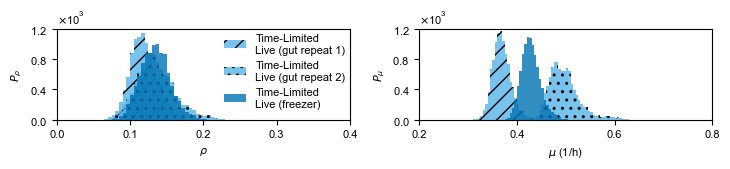

In [19]:
#Figure S10b and c  
import pandas as pd
import matplotlib.pyplot as plt
def format_sci(ax):
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((3, 3))  # force 10^2
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
# Load data
input_path = r"merged_mcmc_all_041526.csv"
df = pd.read_csv(input_path)

# Single group
group = [1, 2, 3]

# Custom colors
exp_colors = {
    1: "#56B4E9",
    2: "#56B4E9",
    3: "#0072B2",
}

exp_hatch = {
    1: "//",   # diagonal
    2: "..",   # dots
    3: "",   # crosshatch
}

exp_labels = {
    1: "Time-Limited\nLive (gut repeat 1)",
    2: "Time-Limited\nLive (gut repeat 2)",
    3: "Time-Limited\nLive (freezer)",
}

# Create figure (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(7.4, 7.2/4))
bins= np.linspace(0,1,201)
# Plot all experiments in same axes
for exp in group:
    subset = df[df["Experiment"] == exp]
    print(f"Experiment {exp}: {len(subset)} samples")

    # rho
    axes[0].hist(
        subset["rho"],
        bins=bins,
        alpha=.8,
        color=exp_colors[exp],
        label=exp_labels[exp],
        hatch=exp_hatch[exp]
    )

    # mu
    axes[1].hist(
        subset["mu"],
        bins=bins,
        alpha=.8,
        color=exp_colors[exp],
        label=exp_labels[exp],
        hatch=exp_hatch[exp]
    )

# Labels
axes[0].set_ylabel(r"$P_{\rho}$")
axes[1].set_ylabel(r"$P_{\mu}$")

axes[0].set_xlabel(r"$\rho$")
axes[1].set_xlabel(r"$\mu$ (1/h)")


# Ticks
axes[0].set_yticks([0, 400, 800, 1200])
axes[1].set_yticks([0, 400, 800, 1200])
# Limits

axes[0].set_xticks([0, 0.1, 0.2, 0.3, 0.4, 1.0])
axes[1].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[0].set_xlim(0, .4)
axes[1].set_xlim(0.2, 0.8)

axes[0].set_ylim(0, 1200)
axes[1].set_ylim(0, 1200)

format_sci(axes[0])
format_sci(axes[1])



# Legends
axes[0].legend(loc="upper right", frameon=False,borderaxespad=0.0    )
#axes[1].legend(loc="upper left", frameon=False)

plt.tight_layout()

plt.savefig(
    r"inferred_mu_rho_grouped_comparisons_histograms_timlim.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

In [20]:
# #
from matplotlib import pyplot as plt
from matplotlib.ticker import ScalarFormatter, LogLocator, FuncFormatter
import pandas as pd

import numpy as np
np.random.seed(42)

# %%
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import os
import matplotlib.pyplot as plt
import re
import seaborn as sns
import pylab
from cycler import cycler
from matplotlib.ticker import FuncFormatter
params = {
    'legend.fontsize': 8,       # Small legend text for compactness
    'figure.figsize': (6.5, 3),  # Figure size (in inches)
    'axes.labelsize': 8,       # Axis labels (X/Y)
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    # 'xtick.major.size': 8,
    # 'ytick.major.size': 8,    
    'axes.titlesize': 8,       # Title size
    'xtick.labelsize': 8,      # X-axis tick labels
    'ytick.labelsize': 8,      # Y-axis tick labels
    'lines.markersize': 5,     # Marker size
    'lines.linewidth': 1        # Line width
}
pylab.rcParams.update(params)

np.random.seed(42)

custom_palette = [
    "#7A1F63",
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",   # reddish purple
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
]


import numpy as np

def rotate_points(x, y, theta_deg):
    theta = np.deg2rad(theta_deg)
    x_rot = x * np.cos(theta) + y * np.sin(theta)
    y_rot = -x * np.sin(theta) + y * np.cos(theta)
    return x_rot, y_rot


sns.set_palette(custom_palette)
# Line styles to cycle through
linestyles = ['-', '-','--', '--', '-.', ':', '-']
sealines = ['', '', (6, 4), (6, 4), (3, 5, 1, 5), (1, 3), '']
# Combine colors and linestyles using cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=custom_palette) + cycler(linestyle=linestyles)

import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import numpy as np

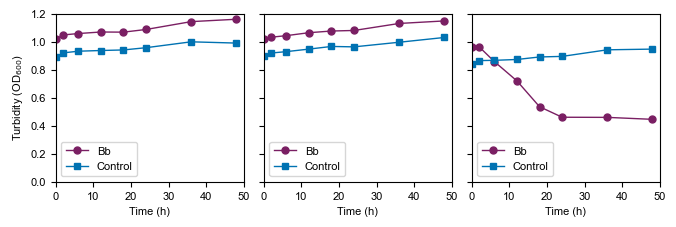

In [21]:
#Figure S5
import pandas as pd
import matplotlib.pyplot as plt


file58 = r"ST094_Media_5_8_high_salt.csv"
file73 = r"ST094_Media_7_3_high_salt.csv"
file73ls = r"ST094_Media_7_3_low_salt.csv"

files = [file58, file73, file73ls]
titles = [
    "Media 5/8 High salt",
    "Media 7/3 High salt",
    "Media 7/3 Low salt"
]


dfs = [pd.read_csv(f) for f in files]

fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.5), sharex=True, sharey=True)

for ax, df, title in zip(axes, dfs, titles):

    ax.plot(
        df["Time"],
        df["Bb"],
        marker='o',
        label="Bb"
    )

    ax.plot(
        df["Time"],
        df["Control"],
        marker='s',
        label="Control"
    )

    #ax.set_title(title)
    ax.set_xlabel("Time (h)")
    ax.set_ylim(0, 1.2)
    ax.set_xlim(0, 50)
    ax.legend()
axes[0].set_ylabel("Turbidity (OD$_{600}$)")


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(r"predation_media.svg",format='svg')
plt.show()


kappa range: (np.float64(0.0), np.float64(1724272.0)) len: 1724273
p sum: 0.9999999999999999


C:\Users\stani\AppData\Local\Temp\ipykernel_33620\244029563.py:29: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0,1500000)


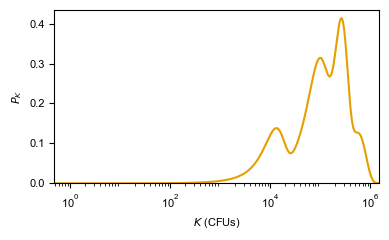

In [22]:
#Figure S9
import numpy as np
import matplotlib.pyplot as plt

# Load and plot the reconstructed Day-9 capacity distribution (should have 4 Guassians)

dat = np.load("capacity_day9_repop_precalibration_highpH.npz")
kappa = dat["kappa"].astype(np.float64).reshape(-1)
p     = dat["p"].astype(np.float64).reshape(-1)
p     = p / p.sum()

# Sanity
print("kappa range:", (kappa.min(), kappa.max()), "len:", len(kappa))
print("p sum:", p.sum())

# Plot as a line (discrete PMF; line is fine for visualization)
fig, ax = plt.subplots(figsize=(4, 2.5))

ax.plot(kappa, kappa * p, lw=1.5,color="#E69F00")

ax.set_xscale("log")
ax.set_xlabel(r"$K$ (CFUs)")
ax.set_ylabel(r"$P_{K}$")
ax.set_ylim(0,)
ax.set_yticks(np.arange(0, 0.41, 0.1))
#ax.set_title("REPOP Reconstruction of Day 9 (Capacity Distribution)")
# ax.set_yticks([])
ax.set_xticks([1,100,10000,1000000])
ax.set_xlim(0,1500000)
plt.tight_layout()
plt.savefig(
    r"capacity_day9_repop_precalibration_highpH.svg",
    bbox_inches='tight',
    format='svg'
)
plt.show()


In [23]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pylab
import matplotlib as mpl
from cycler import cycler
from matplotlib.ticker import FuncFormatter, ScalarFormatter, LogLocator
import matplotlib.ticker as ticker

# === Set Random Seed ===
np.random.seed(42)

# === Plot Styling ===
params = {
    "legend.fontsize": 8,
    "figure.figsize": (6.5, 3),
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.titlesize": 8,
    "lines.markersize": 5,
    "lines.linewidth": 1,
}
pylab.rcParams.update(params)

mpl.rcParams["font.family"] = "Arial"  # change if needed

# === Custom Color Palette ===
custom_palette = [
    "#CC79A7",
    "#0072B2",
    "#E69F00",
    "#009E73",
    "#7A1F63",
    "#D55E00",
    "#56B4E9",
]

sns.set_palette(custom_palette)

linestyles = ["-", "-", "--", "--", "-.", ":", "-"]
plt.rcParams["axes.prop_cycle"] = cycler(color=custom_palette) + cycler(
    linestyle=linestyles
)

C:\Users\stani\AppData\Local\Temp\ipykernel_33620\1312741157.py:95: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


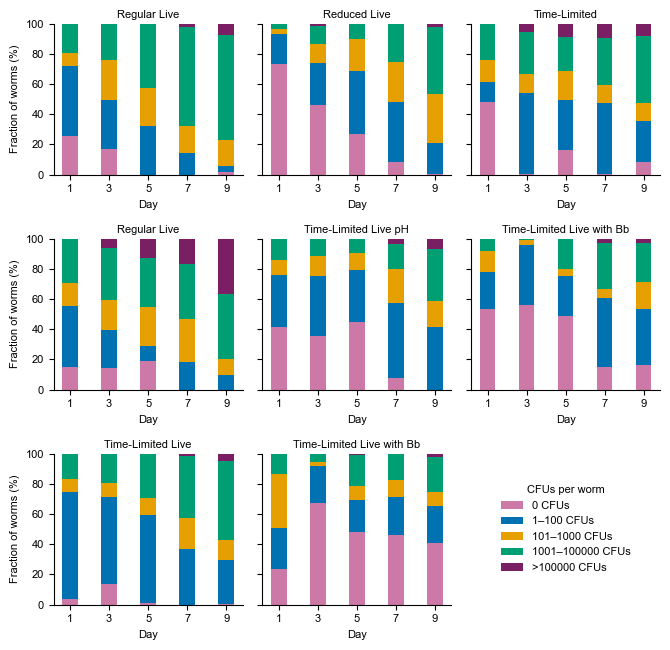

Saved combined figure to: abundance_new_bins.svg


In [24]:
#Figure S1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# === Canonical experiment title map ===
title_map = {
    "Exp_1_Ecoli_population_outputs": "Regular Live",
    "Exp_2_Reduced_live_feed_data_outputs": "Reduced Live",
    "Exp_3_Stochasticity_data_outputs": "Time-Limited",
    "Exp_4_Regular_Feed_pH7.3_data_outputs": "Regular Live",
    "Exp_5_TL_highpH_data_outputs": "Time-Limited Live pH",
    "Exp_6_BB_TL_highpH_outputs": "Time-Limited Live with Bb",
    "Exp_7_low-salinity_time-limited_outputs": "Time-Limited Live",
    "Exp_8_BB_low-salinity_time-limited_outputs": "Time-Limited Live with Bb",
}

def nice_title(exp_name):
    return title_map.get(exp_name, exp_name)

# === Paths ===
SUMMARY_CSV = r"quartile_tail_density_summary3.csv"
OUT_PATH = r"abundance_new_bins.svg"
NCOLS = 3

# === Read data ===
df = pd.read_csv(SUMMARY_CSV)
experiments = sorted(df["experiment"].unique())

n_experiments = len(experiments)
nrows = math.ceil(n_experiments / NCOLS)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=NCOLS,
    figsize=(6.8, 2.2 * nrows),
    sharey=True,
    constrained_layout=True,
)

axes = np.array(axes).reshape(-1)

legend_handles = None
legend_labels = None

# === Plot each experiment ===
for i, (ax, exp) in enumerate(zip(axes, experiments)):
    df_exp = df[df["experiment"] == exp].copy().sort_values("day")
    days = df_exp["day"].to_numpy()

    p0 = df_exp["p0"].to_numpy(dtype=float) * 100
    p1_100 = df_exp["p_1_to_100"].to_numpy(dtype=float) * 100
    p101_1e3 = df_exp["p_101_to_1000"].to_numpy(dtype=float) * 100
    p1e3_1e5 = df_exp["p_1001_to_100000"].to_numpy(dtype=float) * 100
    p_gt1e5 = df_exp["p_gt_100001"].to_numpy(dtype=float) * 100

    width = 0.8

    ax.bar(days, p0, width, label="0 CFUs")
    ax.bar(days, p1_100, width, bottom=p0, label="1–100 CFUs")
    ax.bar(days, p101_1e3, width, bottom=p0 + p1_100, label="101–1000 CFUs")
    ax.bar(days, p1e3_1e5, width, bottom=p0 + p1_100 + p101_1e3, label="1001–100000 CFUs")
    ax.bar(days, p_gt1e5, width, bottom=p0 + p1_100 + p101_1e3 + p1e3_1e5, label=">100000 CFUs")

    ax.set_title(nice_title(exp), pad=4)
    ax.set_xlabel("Day")
    ax.set_ylim(0, 100)
    ax.set_xticks(days)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i % NCOLS == 0:
        ax.set_ylabel("Fraction of worms (%)")

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

# === Turn off unused axes ===
unused_axes = axes[n_experiments:]
for ax in unused_axes:
    ax.axis("off")

# === Place legend in empty axis if any ===
if len(unused_axes) > 0:
    legend_ax = unused_axes[0]
    legend_ax.legend(
        legend_handles,
        legend_labels,
        loc="center",
        frameon=False,
        title="CFUs per worm",
        title_fontsize=8
    )

plt.tight_layout()
fig.savefig(OUT_PATH, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved combined figure to: {OUT_PATH}")

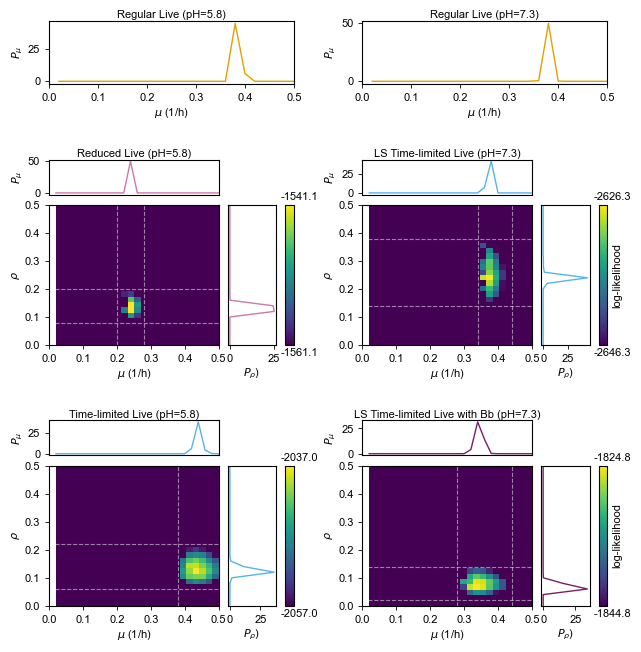

In [ ]:
#Figure S9

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import logsumexp

def crop_by_threshold(A, val, pad=1):
    """
    Returns subarray that contains all entries >= val.
    Everything outside the returned subarray is guaranteed < val.

    pad: optional extra margin (in pixels) to keep around the box.
    """
    A = np.asarray(A)
    mask = A >= val

    if A.ndim != 2:
        cols = np.where(mask)[0]
        return cols[0], cols[-1]

    if mask.all():
        return (0, A.shape[0] - 1, 0, A.shape[1] - 1)

    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]

    r0, r1 = rows[0], rows[-1]
    c0, c1 = cols[0], cols[-1]

    r0 = max(0, r0 - pad)
    c0 = max(0, c0 - pad)
    r1 = min(A.shape[0] - 1, r1 + pad)
    c1 = min(A.shape[1] - 1, c1 + pad)

    return r0, r1, c0, c1


plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.titlesize": 8,
})

results = []

top_titles = ['Exp_1_live_lowpH', 'Exp_4_live_highpH']
grid_titles = [
    'Exp_2_reduced_live_lowpH',
    'Exp_3_time-limited_lowpH',
    'Exp_7_low-salinity_time-limited',
    'Exp_8_BB_low-salinity_time-limited'
]

title_map = {
    'Exp_1_live_lowpH': 'Regular Live (pH=5.8)',
    'Exp_4_live_highpH': 'Regular Live (pH=7.3)',
    'Exp_2_reduced_live_lowpH': 'Reduced Live (pH=5.8)',
    'Exp_3_time-limited_lowpH': 'Time-limited Live (pH=5.8)',
    'Exp_7_low-salinity_time-limited': 'LS Time-limited Live (pH=7.3)',
    'Exp_8_BB_low-salinity_time-limited': 'LS Time-limited Live with Bb (pH=7.3)',
}

color_map = {
    "Exp_1_live_lowpH": "#E69F00",
    "Exp_2_reduced_live_lowpH": "#CC79A7",
    #"Exp_3_time-limited_lowpH": "#0072B2",
    "Exp_3_time-limited_lowpH": "#56B4E9",
    "Exp_4_live_highpH":"#E69F00",# "#D55E00",
    "Exp_7_low-salinity_time-limited": "#56B4E9",
    "Exp_8_BB_low-salinity_time-limited": "#7A1F63",
}

fig = plt.figure(figsize=(7.2, 7.6))
outer = gridspec.GridSpec(
    3, 2, figure=fig,
    height_ratios=[1.2, 3.5, 3.5],
    wspace=0.28,
    hspace=0.52
)

# -----------------------------
# Top row: 1D panels
# -----------------------------
for col, title_1d in enumerate(top_titles):
    ax = fig.add_subplot(outer[0, col])

    df_1d = pd.read_csv(f"grid_likelihood_outputs/{title_1d}/grid_zomega.csv")
    df_1d = df_1d[df_1d["mu"] <= 0.5].copy()

    mu = df_1d["mu"].values
    loglike = df_1d["loglike"].values

    order = np.argsort(mu)
    mu = mu[order]
    loglike = loglike[order]

    loglike = np.nan_to_num(loglike, neginf=-1e6)

    dmu = mu[1] - mu[0]
    pmu = np.exp(loglike - logsumexp(loglike) - np.log(dmu))

    ax.plot(mu, pmu, lw=1.0, color=color_map[title_1d])
    ax.set_xlim(0, 0.5)
    ax.set_xlabel(r"$\mu$ (1/h)", labelpad=2)
    ax.set_ylabel(r"$P_{\mu}$", labelpad=2)
    ax.set_title(title_map[title_1d], pad=2)
    ax.tick_params(direction="out", length=3, width=0.6)

# -----------------------------
# Lower rows: 2D panels
# -----------------------------
placement = {
    'Exp_2_reduced_live_lowpH': (1, 0),
    'Exp_3_time-limited_lowpH': (2, 0),
    'Exp_7_low-salinity_time-limited': (1, 1),
    'Exp_8_BB_low-salinity_time-limited': (2, 1),
}

for title in grid_titles:
    row, col = placement[title]

    df = pd.read_csv(f"grid_likelihood_outputs/{title}/grid_zomega.csv")
    df = df[(df["mu"] <= 0.5) & (df["rho"] <= 0.5)].copy()

    rhos = np.unique(df["rho"].values)
    mus = np.unique(df["mu"].values)

    sh = (mus.size, rhos.size)
    Z = df["loglike"].values.reshape(sh)

    Zeff = Z.clip(min=np.max(Z) - 20)
    Z_rho = logsumexp(Z, axis=0) - logsumexp(Z)
    Z_mu = logsumexp(Z, axis=1) - logsumexp(Z)

    P_rho = np.exp(Z_rho - np.log(rhos[1] - rhos[0]))
    P_mu = np.exp(Z_mu - np.log(mus[1] - mus[0]))

    r0, r1, c0, c1 = crop_by_threshold(Z, Zeff.min())

    results.append({
        "title": title,
        "mu_low": mus[r0],
        "mu_high": mus[r1],
        "rho_low": rhos[c0],
        "rho_high": rhos[c1],
    })

    inner = gridspec.GridSpecFromSubplotSpec(
        2, 3,
        subplot_spec=outer[row, col],
        width_ratios=[4, 1.15, 0.20],
        height_ratios=[1.0, 4],
        hspace=0.12,
        wspace=0.12
    )

    ax_top = fig.add_subplot(inner[0, 0])
    ax_joint = fig.add_subplot(inner[1, 0])
    ax_right = fig.add_subplot(inner[1, 1])
    ax_cbar = fig.add_subplot(inner[1, 2])

    im = ax_joint.imshow(
        Zeff.T,
        extent=[mus.min(), mus.max(), rhos.min(), rhos.max()],
        aspect="auto",
        origin="lower"
    )

    ax_joint.set_xlim(0, 0.5)
    ax_joint.set_ylim(0, 0.5)
    ax_joint.set_xlabel(r"$\mu$ (1/h)", labelpad=2)
    ax_joint.set_ylabel(r"$\rho$", labelpad=2)
    ax_joint.tick_params(direction="out", length=3, width=0.6)

    cbar = fig.colorbar(im, cax=ax_cbar)
    cbar.ax.tick_params(labelsize=8)

    vmin, vmax = im.get_clim()
    cbar = fig.colorbar(im, cax=ax_cbar)

    vmin, vmax = im.get_clim()

    # remove default ticks
    cbar.set_ticks([])

    # add manual labels above and below
    ax_cbar.text(
        1.6, 1.02, f"{vmax:.1f}",
        ha="center", va="bottom",
        transform=ax_cbar.transAxes,
        fontsize=8
    )

    ax_cbar.text(
        1.6, -0.02, f"{vmin:.1f}",
        ha="center", va="top",
        transform=ax_cbar.transAxes,
        fontsize=8
    )

    if title in [
        "Exp_7_low-salinity_time-limited",
        "Exp_8_BB_low-salinity_time-limited"
    ]:
        cbar.set_label("log-likelihood", fontsize=8, labelpad=4)

    ax_top.plot(mus, P_mu, lw=1.0, color=color_map[title])
    ax_top.set_xlim(0, 0.5)
    ax_top.set_xticks([])
    ax_top.set_ylabel(r"$P_{\mu}$", labelpad=2)
    ax_top.set_title(title_map[title], pad=2)
    ax_top.tick_params(direction="out", length=3, width=0.6)

    ax_right.plot(P_rho, rhos, lw=1.0, color=color_map[title])
    ax_right.set_ylim(0, 0.5)
    ax_right.set_yticks([])
    ax_right.set_xlabel(r"$P_{\rho}$)", labelpad=2)
    ax_right.tick_params(direction="out", length=3, width=0.6)

    # Threshold boxes
    ax_joint.axvline(mus[r0], color="white", linestyle="--", alpha=0.5, lw=0.8)
    ax_joint.axvline(mus[r1], color="white", linestyle="--", alpha=0.5, lw=0.8)
    ax_joint.axhline(rhos[c0], color="white", linestyle="--", alpha=0.5, lw=0.8)
    ax_joint.axhline(rhos[c1], color="white", linestyle="--", alpha=0.5, lw=0.8)

plt.savefig(
    r"C:\Users\stani\Stan\Arizona\Crushing\Pics\combined_exp1_4_2_3_7_8.svg",
    dpi=500,
    bbox_inches="tight"
)
plt.show()